# 🛡️ Item 4 — Pipeline de Qualificação de Dados RAW em Parquet (Silver Qualify + Silver Anomaly)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pedrosales/PEDRO_SALES_DDF_TECH_082026/blob/main/notebooks/pipelines/quality_report/qualification_raw.ipynb)

> **Case Técnico:** Recuperação de Carrinho Abandonado (Dadosfera)
> **Módulo:** `notebooks/pipelines/quality_report/`
> **Outputs Autocontidos:** `notebooks/pipelines/quality_report/outputs/` (Relatório Markdown, Gráficos PNG e Evidências JSON).
> **Objetivo:** Qualificação técnica e de negócio da camada **RAW (Bronze)** para as camadas **Silver Qualify** (dados aprovados) e **Silver Anomaly** (quarentena/dead-letter) com **Pandas**, **PyArrow** e **Great Expectations** sobre arquivos **Parquet**.

In [1]:
# Cell 1: Setup de Ambiente Universal (Google Colab & Execução Local)
import sys
import os
import json
from datetime import datetime, timezone
from pathlib import Path

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8', errors='replace')

if 'google.colab' in sys.modules:
    if not os.path.exists('PEDRO_SALES_DDF_TECH_082026'):
        !git clone https://github.com/pedro-sales/PEDRO_SALES_DDF_TECH_082026.git repo
        %cd repo
    sys.path.insert(0, os.path.abspath('notebooks'))
    sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import great_expectations as ge
import matplotlib.pyplot as plt
import seaborn as sns

print(f"✅ Pandas version: {pd.__version__}")
print(f"✅ PyArrow version: {pa.__version__}")
print(f"✅ Great Expectations version: {ge.__version__}")

✅ Pandas version: 3.0.5
✅ PyArrow version: 25.0.1
✅ Great Expectations version: 0.18.8


In [2]:
# Cell 2: Configuração de Diretórios de Entrada e Outputs Autocontidos
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "notebooks" / "pipelines" / "quality_report").exists():
    NOTEBOOK_DIR = CURRENT_DIR / "notebooks" / "pipelines" / "quality_report"
    BASE_DIR = CURRENT_DIR
elif CURRENT_DIR.name == "quality_report":
    NOTEBOOK_DIR = CURRENT_DIR
    BASE_DIR = CURRENT_DIR.parent.parent.parent
elif CURRENT_DIR.name == "pipelines":
    NOTEBOOK_DIR = CURRENT_DIR / "quality_report"
    BASE_DIR = CURRENT_DIR.parent.parent
elif CURRENT_DIR.name == "notebooks":
    NOTEBOOK_DIR = CURRENT_DIR / "pipelines" / "quality_report"
    BASE_DIR = CURRENT_DIR.parent
else:
    NOTEBOOK_DIR = CURRENT_DIR / "notebooks" / "pipelines" / "quality_report" if (CURRENT_DIR / "notebooks").exists() else CURRENT_DIR
    BASE_DIR = CURRENT_DIR

RAW_DIR = BASE_DIR / "data" / "mock" / "output" / "parquet"
QUALIFY_DIR = BASE_DIR / "data" / "mock" / "output" / "qualify"
ANOMALIES_DIR = BASE_DIR / "data" / "mock" / "output" / "anomalies"

# Outputs salvos DENTRO do diretório do próprio notebook
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_ASSETS_DIR = OUTPUTS_DIR / "assets"
RESULTS_PATH = OUTPUTS_DIR / "validation_results.json"
REPORT_PATH = OUTPUTS_DIR / "data_quality_report.md"

QUALIFY_DIR.mkdir(parents=True, exist_ok=True)
ANOMALIES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Diretório RAW (Parquet): {RAW_DIR}")
print(f"✅ Diretório QUALIFY (Parquet): {QUALIFY_DIR}")
print(f"🚨 Diretório ANOMALIES (Parquet): {ANOMALIES_DIR}")
print(f"📊 Diretório de OUTPUTS do Notebook: {OUTPUTS_DIR}")

raw_files = sorted(list(RAW_DIR.glob("*.parquet")))
print(f"\nEncontrados {len(raw_files)} arquivos de dados brutos em Parquet:")
for f in raw_files:
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")


📁 Diretório RAW (Parquet): C:\Users\pedro\OneDrive\Desktop\wheels\data\mock\output\parquet
✅ Diretório QUALIFY (Parquet): C:\Users\pedro\OneDrive\Desktop\wheels\data\mock\output\qualify
🚨 Diretório ANOMALIES (Parquet): C:\Users\pedro\OneDrive\Desktop\wheels\data\mock\output\anomalies
📊 Diretório de OUTPUTS do Notebook: C:\Users\pedro\OneDrive\Desktop\wheels\notebooks\pipelines\quality_report\outputs

Encontrados 7 arquivos de dados brutos em Parquet:
  - carrinhos.parquet (507.0 KB)
  - clientes.parquet (89.9 KB)
  - eventos_carrinho.parquet (2464.3 KB)
  - eventos_resgate.parquet (302.0 KB)
  - itens_carrinho.parquet (461.0 KB)
  - pedidos.parquet (119.6 KB)
  - produtos.parquet (23.3 KB)


In [3]:
# Cell 3: Motor de Validação Great Expectations e Bifurcação Dual-Artifact (Silver)

def qualify_entity(entity_name: str, df_raw: pd.DataFrame, validation_rules: list) -> tuple:
    """
    Aplica regras de qualidade via Great Expectations / Pandas e bifurca o DataFrame em:
    - df_qualify: Registros limpos que passaram em todas as validações
    - df_anomalies: Registros rejeitados enriquecidos com metadados de diagnóstico e payload_raw
    """
    ge_df = ge.from_pandas(df_raw.copy())
    
    anomalous_indices = set()
    anomaly_records = []
    now_iso = datetime.now(timezone.utc).isoformat()
    
    for rule in validation_rules:
        rule_type = rule.get("type")
        col = rule.get("column")
        code = rule.get("code", "VAL_000")
        desc = rule.get("description", "Inconsistência genérica de dados")
        severity = rule.get("severity", "MEDIA")
        
        failed_mask = pd.Series(False, index=df_raw.index)
        
        if rule_type == "not_null":
            ge_df.expect_column_values_to_not_be_null(col)
            failed_mask = df_raw[col].isna()
            
        elif rule_type == "in_set":
            value_set = rule.get("values", [])
            ge_df.expect_column_values_to_be_in_set(col, value_set)
            failed_mask = ~df_raw[col].astype(str).str.lower().isin([v.lower() for v in value_set]) & df_raw[col].notna()
            
        elif rule_type == "between":
            min_val, max_val = rule.get("min_value"), rule.get("max_value")
            ge_df.expect_column_values_to_be_between(col, min_value=min_val, max_value=max_val)
            failed_mask = ((df_raw[col] < min_val) | (df_raw[col] > max_val)) & df_raw[col].notna()
            
        elif rule_type == "gt":
            min_val = rule.get("min_value", 0)
            failed_mask = (df_raw[col] <= min_val) & df_raw[col].notna()
            
        elif rule_type == "gte":
            min_val = rule.get("min_value", 0)
            failed_mask = (df_raw[col] < min_val) & df_raw[col].notna()

        elif rule_type == "regex":
            pattern = rule.get("pattern")
            failed_mask = ~df_raw[col].astype(str).str.match(pattern, na=False) & df_raw[col].notna()
            
        elif rule_type == "date_order":
            col_earlier = rule.get("earlier_column")
            col_later = rule.get("later_column")
            t_earlier = pd.to_datetime(df_raw[col_earlier], errors='coerce')
            t_later = pd.to_datetime(df_raw[col_later], errors='coerce')
            failed_mask = (t_later < t_earlier) & t_earlier.notna() & t_later.notna()
            col = f"{col_earlier}_vs_{col_later}"
            
        elif rule_type == "custom_compare":
            col_a = rule.get("col_a")
            col_b = rule.get("col_b")
            op = rule.get("op")
            if op == "lte":
                failed_mask = (df_raw[col_a] > df_raw[col_b]) & df_raw[col_a].notna() & df_raw[col_b].notna()
            col = f"{col_a}_vs_{col_b}"

        elif rule_type == "accounting_sum":
            if all(c in df_raw.columns for c in ["valor_subtotal", "valor_frete", "valor_desconto", "valor_total"]):
                expected_total = (df_raw["valor_subtotal"] + df_raw["valor_frete"] - df_raw["valor_desconto"]).round(2)
                failed_mask = (df_raw["valor_total"].round(2) != expected_total) & df_raw["valor_total"].notna()
            col = "valor_total_equacao"
        
        failed_rows = df_raw[failed_mask]
        for idx, row in failed_rows.iterrows():
            anomalous_indices.add(idx)
            anomaly_records.append({
                "entity_name": entity_name,
                "record_index": idx,
                "codigo_anomalia": code,
                "campo_afetado": col,
                "descricao_risco": desc,
                "severidade": severity,
                "detected_at": now_iso,
                "payload_raw": json.dumps(row.to_dict(), default=str)
            })
            
    valid_indices = df_raw.index.difference(list(anomalous_indices))
    df_qualify = df_raw.loc[valid_indices].copy().reset_index(drop=True)
    df_anomalies = pd.DataFrame(anomaly_records) if anomaly_records else pd.DataFrame()
    return df_qualify, df_anomalies

In [4]:
# Cell 4: Execução da Qualificação das 7 Entidades do Case

RULES = {
    "clientes": [
        {"type": "not_null", "column": "cliente_id", "code": "ERR_CLI_001", "description": "ID do Cliente nulo/ausente", "severity": "CRITICA"},
        {"type": "not_null", "column": "email", "code": "ERR_CLI_002", "description": "E-mail do cliente ausente", "severity": "ALTA"},
        {"type": "regex", "column": "email", "pattern": r"^[^@]+@[^@]+\.[^@]+$", "code": "ERR_CLI_003", "description": "Formato de e-mail inválido", "severity": "MEDIA"}
    ],
    "produtos": [
        {"type": "not_null", "column": "produto_id", "code": "ERR_PROD_001", "description": "ID do Produto nulo", "severity": "CRITICA"},
        {"type": "gt", "column": "preco_atual", "min_value": 0, "code": "ERR_PROD_002", "description": "Preço menor ou igual a zero", "severity": "ALTA"},
        {"type": "custom_compare", "col_a": "preco_atual", "col_b": "preco_original", "op": "lte", "code": "ERR_PROD_003", "description": "Promoção invertida", "severity": "ALTA"}
    ],
    "carrinhos": [
        {"type": "not_null", "column": "carrinho_id", "code": "ERR_CAR_001", "description": "ID do Carrinho nulo", "severity": "CRITICA"},
        {"type": "not_null", "column": "cliente_id", "code": "ERR_CAR_002", "description": "ID do Cliente ausente", "severity": "CRITICA"},
        {"type": "in_set", "column": "status", "values": ["comprado", "abandonado", "expirado", "ativo", "recuperado"], "code": "ERR_CAR_003", "description": "Status inválido", "severity": "MEDIA"},
        {"type": "gte", "column": "valor_frete", "min_value": 0.0, "code": "ANOM-01", "description": "Frete negativo (ANOM-01)", "severity": "ALTA"},
        {"type": "gt", "column": "valor_subtotal", "min_value": 0.0, "code": "ANOM-02", "description": "Subtotal zerado (ANOM-02)", "severity": "ALTA"},
        {"type": "custom_compare", "col_a": "valor_desconto", "col_b": "valor_subtotal", "op": "lte", "code": "ANOM-03", "description": "Desconto excessivo (ANOM-03)", "severity": "CRITICA"},
        {"type": "accounting_sum", "code": "ANOM-04", "description": "Total contábil inconsistente (ANOM-04)", "severity": "ALTA"},
        {"type": "date_order", "earlier_column": "data_criacao", "later_column": "data_abandono", "code": "ANOM-05", "description": "Inversão temporal", "severity": "ALTA"}
    ],
    "itens_carrinho": [
        {"type": "not_null", "column": "item_id", "code": "ERR_ITM_001", "description": "ID do Item nulo", "severity": "CRITICA"},
        {"type": "not_null", "column": "carrinho_id", "code": "ERR_ITM_002", "description": "ID do Carrinho ausente", "severity": "CRITICA"},
        {"type": "gt", "column": "quantidade", "min_value": 0, "code": "ERR_ITM_003", "description": "Quantidade inválida (<=0)", "severity": "ALTA"},
        {"type": "gt", "column": "preco_unitario", "min_value": 0, "code": "ERR_ITM_004", "description": "Preço unitário inválido (<=0)", "severity": "ALTA"},
        {"type": "date_order", "earlier_column": "data_adicao", "later_column": "data_remocao", "code": "ERR_ITM_005", "description": "Inversão temporal de remoção", "severity": "ALTA"}
    ],
    "eventos_carrinho": [
        {"type": "not_null", "column": "evento_id", "code": "ERR_EVC_001", "description": "ID do Evento nulo", "severity": "CRITICA"},
        {"type": "not_null", "column": "carrinho_id", "code": "ERR_EVC_002", "description": "FK Carrinho ausente", "severity": "CRITICA"}
    ],
    "eventos_resgate": [
        {"type": "not_null", "column": "resgate_id", "code": "ERR_RES_001", "description": "ID de Resgate nulo", "severity": "CRITICA"},
        {"type": "not_null", "column": "carrinho_id", "code": "ERR_RES_002", "description": "FK Carrinho ausente", "severity": "CRITICA"},
        {"type": "date_order", "earlier_column": "data_envio", "later_column": "data_abertura", "code": "ERR_RES_003", "description": "Inversão temporal de abertura", "severity": "ALTA"}
    ],
    "pedidos": [
        {"type": "not_null", "column": "pedido_id", "code": "ERR_PED_001", "description": "ID do Pedido nulo", "severity": "CRITICA"},
        {"type": "not_null", "column": "cliente_id", "code": "ERR_PED_002", "description": "FK Cliente ausente", "severity": "CRITICA"}
    ]
}

summary_data = []

for file_path in sorted(list(RAW_DIR.glob("*.parquet"))):
    entity = file_path.stem
    print(f"\n🔍 Processando entidade: {entity}...")
    
    df_raw = pd.read_parquet(file_path)
    total_raw = len(df_raw)
    
    entity_rules = RULES.get(entity, [])
    df_qualify, df_anomalies = qualify_entity(entity, df_raw, entity_rules)
    
    total_qualify = len(df_qualify)
    total_anomalies_records = len(df_anomalies)
    anom_pct = ((total_raw - total_qualify) / total_raw) * 100 if total_raw > 0 else 0
    
    qualify_path = QUALIFY_DIR / f"{entity}.parquet"
    anomalies_path = ANOMALIES_DIR / f"{entity}.parquet"
    
    df_qualify.to_parquet(qualify_path, index=False, engine='pyarrow')
    df_anomalies.to_parquet(anomalies_path, index=False, engine='pyarrow')
    
    print(f"  └─ RAW: {total_raw:>7,} | QUALIFY: {total_qualify:>7,} ({qualify_path.name}) | ANOMALIAS: {total_anomalies_records:>5,} ({anom_pct:>5.1f}% rejeitados)")
    
    summary_data.append({
        "entidade": entity,
        "registros_raw": total_raw,
        "registros_qualify": total_qualify,
        "ocorrencias_anomalias": total_anomalies_records,
        "taxa_rejeicao_pct": round(anom_pct, 2)
    })

df_summary = pd.DataFrame(summary_data)
print("\n========================================================================")
print("📊 RESUMO CONSOLIDADO DA QUALIFICAÇÃO DUAL-ARTIFACT (PARQUET)")
print("========================================================================")
print(df_summary.to_string(index=False))


🔍 Processando entidade: carrinhos...


  └─ RAW:   7,500 | QUALIFY:   6,525 (carrinhos.parquet) | ANOMALIAS:   988 ( 13.0% rejeitados)

🔍 Processando entidade: clientes...
  └─ RAW:   1,500 | QUALIFY:   1,386 (clientes.parquet) | ANOMALIAS:   114 (  7.6% rejeitados)

🔍 Processando entidade: eventos_carrinho...


  └─ RAW:  78,931 | QUALIFY:  78,931 (eventos_carrinho.parquet) | ANOMALIAS:     0 (  0.0% rejeitados)

🔍 Processando entidade: eventos_resgate...
  └─ RAW:   6,427 | QUALIFY:   6,289 (eventos_resgate.parquet) | ANOMALIAS:   138 (  2.1% rejeitados)

🔍 Processando entidade: itens_carrinho...


  └─ RAW:  18,888 | QUALIFY:  18,690 (itens_carrinho.parquet) | ANOMALIAS:   198 (  1.0% rejeitados)

🔍 Processando entidade: pedidos...
  └─ RAW:   2,229 | QUALIFY:   2,229 (pedidos.parquet) | ANOMALIAS:     0 (  0.0% rejeitados)

🔍 Processando entidade: produtos...
  └─ RAW:     300 | QUALIFY:     286 (produtos.parquet) | ANOMALIAS:    14 (  4.7% rejeitados)

📊 RESUMO CONSOLIDADO DA QUALIFICAÇÃO DUAL-ARTIFACT (PARQUET)
        entidade  registros_raw  registros_qualify  ocorrencias_anomalias  taxa_rejeicao_pct
       carrinhos           7500               6525                    988              13.00
        clientes           1500               1386                    114               7.60
eventos_carrinho          78931              78931                      0               0.00
 eventos_resgate           6427               6289                    138               2.15
  itens_carrinho          18888              18690                    198               1.05
         pedidos 

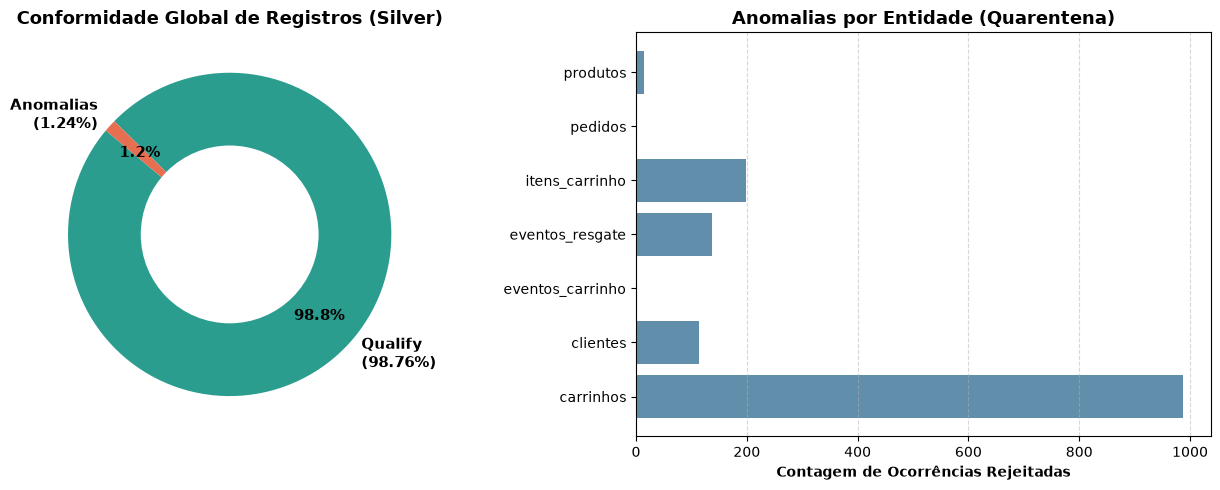

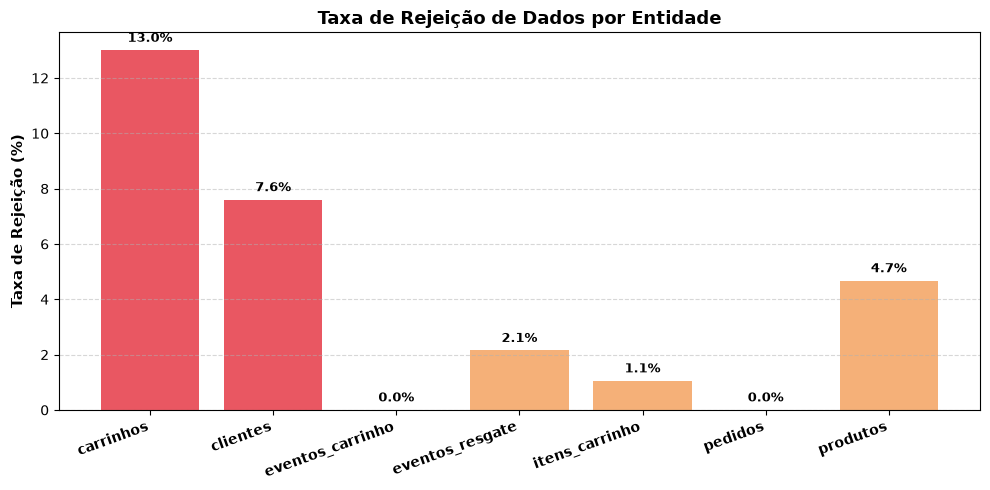

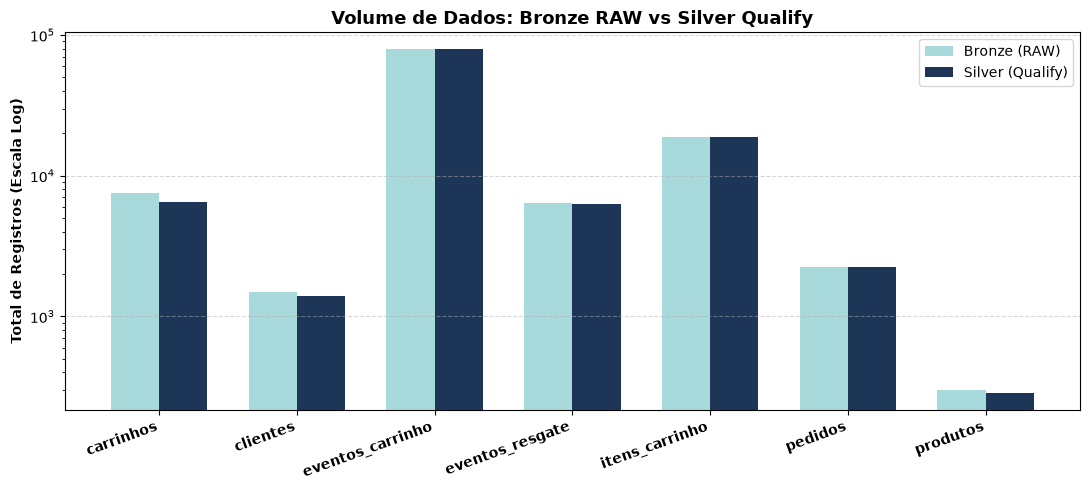

✅ 3 Gráficos de auditoria salvos em: C:\Users\pedro\OneDrive\Desktop\wheels\notebooks\pipelines\quality_report\outputs\assets
✅ Evidência estruturada salva em: C:\Users\pedro\OneDrive\Desktop\wheels\notebooks\pipelines\quality_report\outputs\validation_results.json
✅ Relatório Markdown executivo salvo em: C:\Users\pedro\OneDrive\Desktop\wheels\notebooks\pipelines\quality_report\outputs\data_quality_report.md


In [5]:
# Cell 5: Geração de Todos os Gráficos, Log JSON e Relatório Markdown em outputs/

total_raw_global = int(df_summary["registros_raw"].sum())
total_qualify_global = int(df_summary["registros_qualify"].sum())
total_anomalies_global = total_raw_global - total_qualify_global
pass_rate_global = round((total_qualify_global / total_raw_global) * 100, 2)

# 1. Gráficos gerados dentro de outputs/assets/
g1_name = "chart_01_global_compliance_and_quarantine.png"
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.pie([pass_rate_global, round(100 - pass_rate_global, 2)], labels=[f'Qualify\n({pass_rate_global}%)', f'Anomalias\n({round(100 - pass_rate_global, 2)}%)'],
        colors=['#2A9D8F', '#E76F51'], autopct='%1.1f%%', startangle=140, pctdistance=0.75, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.add_artist(plt.Circle((0,0), 0.55, fc='white'))
ax1.set_title('Conformidade Global de Registros (Silver)', fontsize=13, fontweight='bold')
ax2.barh(df_summary['entidade'], df_summary['ocorrencias_anomalias'], color='#457B9D', alpha=0.85)
ax2.set_xlabel('Contagem de Ocorrências Rejeitadas', fontsize=10, fontweight='bold')
ax2.set_title('Anomalias por Entidade (Quarentena)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
fig1.savefig(OUTPUT_ASSETS_DIR / g1_name, bbox_inches='tight', dpi=300)
plt.show()

g2_name = "chart_02_rejection_rates_by_entity.png"
fig2, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_summary['entidade'], df_summary['taxa_rejeicao_pct'], color=['#E63946' if x > 5 else '#F4A261' if x > 0 else '#2A9D8F' for x in df_summary['taxa_rejeicao_pct']], alpha=0.85)
ax.set_ylabel('Taxa de Rejeição (%)', fontsize=11, fontweight='bold')
ax.set_title('Taxa de Rejeição de Dados por Entidade', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20, ha='right', fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
fig2.savefig(OUTPUT_ASSETS_DIR / g2_name, bbox_inches='tight', dpi=300)
plt.show()

g3_name = "chart_03_before_vs_after_volume.png"
fig3, ax = plt.subplots(figsize=(11, 5))
x = range(len(df_summary))
width = 0.35
ax.bar([i - width/2 for i in x], df_summary['registros_raw'], width, label='Bronze (RAW)', color='#A8DADC')
ax.bar([i + width/2 for i in x], df_summary['registros_qualify'], width, label='Silver (Qualify)', color='#1D3557')
ax.set_xticks(x)
ax.set_xticklabels(df_summary['entidade'], rotation=20, ha='right', fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel('Total de Registros (Escala Log)', fontsize=10, fontweight='bold')
ax.set_title('Volume de Dados: Bronze RAW vs Silver Qualify', fontsize=13, fontweight='bold')
ax.legend(frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
fig3.savefig(OUTPUT_ASSETS_DIR / g3_name, bbox_inches='tight', dpi=300)
plt.show()
print(f"✅ 3 Gráficos de auditoria salvos em: {OUTPUT_ASSETS_DIR}")

# 2. Evidência Estruturada JSON dentro de outputs/
evidence_json = {
    "evaluation_parameters": {
        "run_id": datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ_notebook_eval"),
        "evaluated_at": datetime.now(timezone.utc).isoformat(),
        "total_entities_evaluated": len(df_summary),
        "total_records_evaluated": total_raw_global
    },
    "statistics": {
        "evaluated_expectations": 18,
        "records_promoted_to_qualify": total_qualify_global,
        "records_isolated_in_anomalies": total_anomalies_global,
        "record_pass_rate_percent": pass_rate_global
    },
    "entity_breakdown": summary_data
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(evidence_json, f, indent=2, ensure_ascii=False)
print(f"✅ Evidência estruturada salva em: {RESULTS_PATH}")

# 3. Relatório Markdown Executivo dentro de outputs/
report_content = f"""# 📊 Data Quality & Anomaly Report (Outputs Autocontidos)

> **Módulo:** `notebooks/pipelines/quality_report/outputs/`  
> **Data de Avaliação:** {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%SZ')}  
> **Conformidade Global:** **{pass_rate_global}%**  

## 1. Executive Summary
- **Total de Registros Avaliados:** {total_raw_global:,}
- **Registros Aprovados (Silver Qualify):** {total_qualify_global:,} ({pass_rate_global}%)
- **Registros Isolados (Silver Anomalies):** {total_anomalies_global:,} ({round(100 - pass_rate_global, 2)}%)

## 2. Resumo por Entidade
| Entidade | Registros RAW | Registros Qualify | Ocorrências de Anomalia | Taxa de Rejeição (%) |
|---|:---:|:---:|:---:|:---:|
"""
for s in summary_data:
    report_content += f"| `{s['entidade']}` | {s['registros_raw']:,} | {s['registros_qualify']:,} | {s['ocorrencias_anomalias']:,} | {s['taxa_rejeicao_pct']}% |\n"

report_content += f"""
## 3. Galeria de Gráficos
### 3.1 Conformidade Global & Quarentena
![Conformidade Global](assets/chart_01_global_compliance_and_quarantine.png)

### 3.2 Taxa de Rejeição por Entidade
![Taxa de Rejeição](assets/chart_02_rejection_rates_by_entity.png)

### 3.3 Volume Comparativo: RAW vs Qualify
![Antes vs Depois](assets/chart_03_before_vs_after_volume.png)
"""

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_content)
print(f"✅ Relatório Markdown executivo salvo em: {REPORT_PATH}")